<a href="https://colab.research.google.com/github/anjalishinde06/HPC-PROJECT/blob/main/HPC_Project_Stock_Price_Predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Predicting Stock Prices Using Regression Analysis

# Standard data imports
import pandas as pd
import numpy as np

# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn metrics, functions and models
from sklearn import metrics


In [ ]:
# Load CSV dataset (replace 'GOOG.csv' with your dataset path)
df = pd.read_excel('/content/1729258-1613615-Stock_Price_data_set_(1).xlsx')

# Show first 5 rows
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
# Shape of dataset
df.shape


(1009, 7)

In [ ]:
# Drop unnecessary columns
# The previous list of columns caused a KeyError because they were not found in the DataFrame.
# The DataFrame contains 'Adj Close', so we will drop that if it's considered unnecessary.
# Other columns like 'symbol', 'adjHigh', etc., were not found.
columns_to_drop = ['Adj Close'] # Corrected column name to match the DataFrame

# Filter to only drop columns that actually exist to prevent KeyError
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop, axis=1)
    print(f"Dropped columns: {existing_cols_to_drop}")
else:
    print("No specified columns found to drop.")

df.head()


Dropped columns: ['Adj Close']


,Date,Open,High,Low,Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,16906900


In [ ]:
# Check duplicates
df.duplicated().sum()


np.int64(0)

In [ ]:
# Check null values
df.isnull().values.any()


np.False_

In [ ]:
# DataFrame info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1009 non-null   datetime64[ns]
 1   Open    1009 non-null   float64       
 2   High    1009 non-null   float64       
 3   Low     1009 non-null   float64       
 4   Close   1009 non-null   float64       
 5   Volume  1009 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.4 KB


In [ ]:
# Descriptive statistics
df.describe()


,Date,Open,High,Low,Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,2020-02-05 07:30:58.870168320,419.059673,425.320703,412.374044,419.000733,7.570685e+06
min,2018-02-05 00:00:00,233.919998,250.649994,231.229996,233.880005,1.144000e+06
25%,2019-02-06 00:00:00,331.489990,336.299988,326.000000,331.619995,4.091900e+06
50%,2020-02-06 00:00:00,377.769989,383.010010,370.880005,378.670013,5.934500e+06
75%,2021-02-05 00:00:00,509.130005,515.630005,502.529999,509.079987,9.322400e+06
max,2022-02-04 00:00:00,692.349976,700.989990,686.090027,691.690002,5.890430e+07
std,NaN,108.537532,109.262960,107.555867,108.289999,5.465535e+06


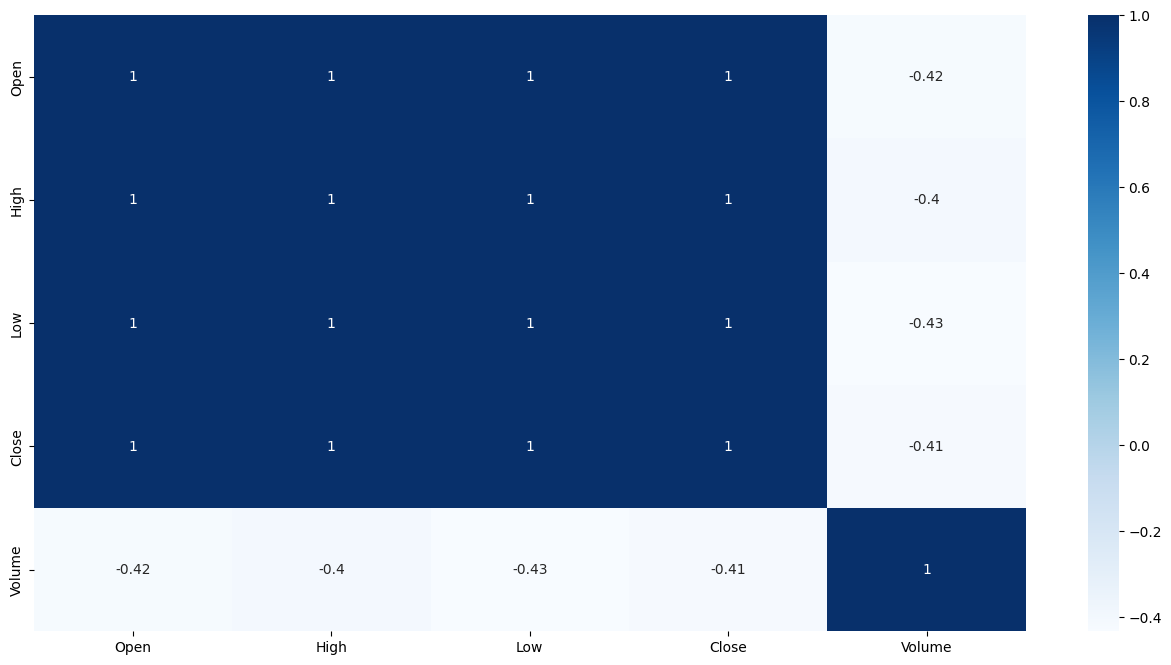

In [ ]:
# Heatmap
plt.figure(figsize=(16,8))
sns.heatmap(df.drop(columns=['Date']).corr(), cmap="Blues", annot=True)
plt.show()

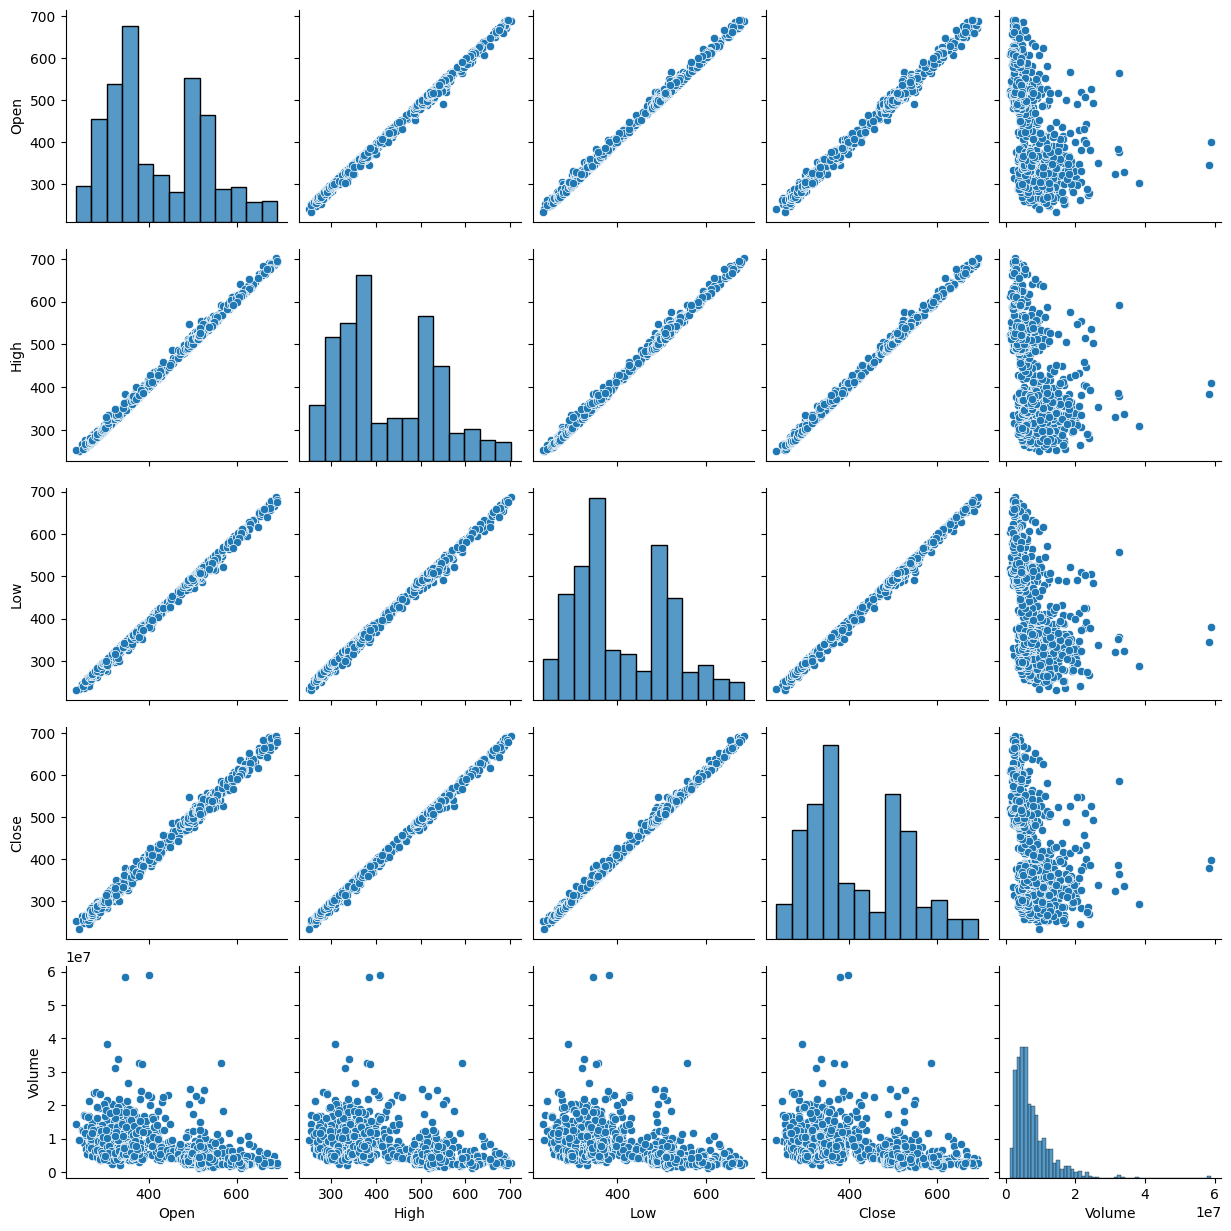

In [ ]:
# Pairplot
sns.pairplot(df)


<Axes: >

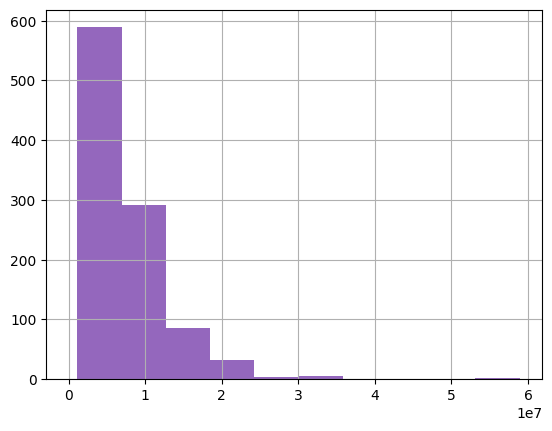

In [ ]:
# Histograms
df['Open'].hist()
df['High'].hist()
df['Low'].hist()
df['Close'].hist()
df['Volume'].hist()

In [ ]:
# Independent & dependent variables
X = df[['Open', 'High', 'Low', 'Volume']].values
y = df['Close'].values

# Split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print('Train:', X_train.shape)
print('Test:', X_test.shape)


Train: (807, 4)
Test: (202, 4)


In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Train model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict
y_pred = regressor.predict(X_test)


In [ ]:
# Coefficients & intercept
print("Model Coefficients:", regressor.coef_)
print("Model Intercept:", regressor.intercept_)


Model Coefficients: [-6.08525352e-01  7.52637059e-01  8.57461003e-01  9.16527847e-08]
Model Intercept: -0.479062525175209


In [ ]:
# OLS regression
results3 = sm.OLS(y_test, X_test).fit()
results3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          5.890e+05
Date:                Sat, 04 Apr 2026   Prob (F-statistic):                        0.00
Time:                        04:09:59   Log-Likelihood:                         -566.80
No. Observations:                 202   AIC:                                      1142.
Df Residuals:                     198   BIC:                                      1155.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.5319      0.060     -8.865      0.000      -0.650      -0.414
x2             0.8398      0.060     13.983      0.000       0.721       0.958
x3             0.6898      0.060     11.473      0.000       0.571       0.808
x4          8.967e-08    5.8e-08      1.546      0.124   -2.47e-08    2.04e-07
==============================================================================
Omnibus:                       21.636   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.109
Skew:                           0.387   Prob(JB):                     8.86e-14
Kurtosis:                       5.558   Cond. No.                     2.27e+06
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.27e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Regression confidence
print("Linear regression confidence:", regressor.score(X_test, y_test))


Linear regression confidence: 0.9984917455237636


In [ ]:
# Error metrics
import math
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', math.sqrt(metrics.mean_squared_error(y_test, y_pred)))


Mean Absolute Error: 2.9013198795458566
Mean Squared Error: 16.993648468986148
Root Mean Squared Error: 4.12233531738821


In [ ]:
# Accuracy
x2 = abs(y_pred - y_test)
y2 = 100 * (x2 / y_test)
accuracy = 100 - np.mean(y2)
print('Accuracy:', round(accuracy, 2), '%.')


Accuracy: 99.31 %.


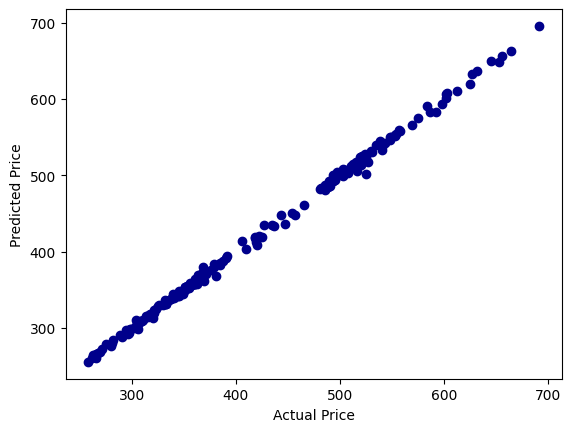

In [ ]:
# Scatter Plot
plt.scatter(dfr.Actual_Price, dfr.Predicted_Price, color='Darkblue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


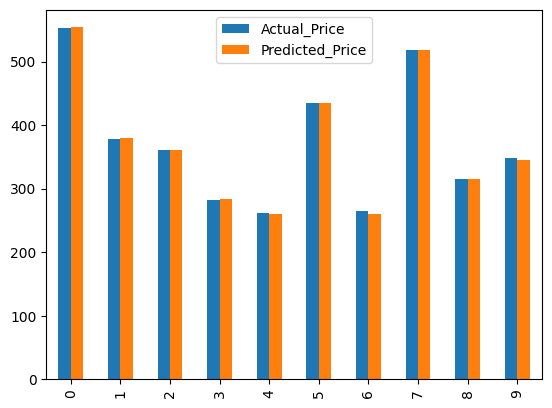

In [ ]:
# Bar Graph (first 10 values)
dfr.head(10).plot(kind='bar')
plt.show()


## Long Short-Term Memory (LSTM) Model

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
        Date        Open        High         Low       Close   Adj Close  \
0 2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1 2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2 2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3 2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4 2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  

Training Samples: (758, 60, 1)
Testing Samples: (190, 60, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0359 - val_loss: 0.0594
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0073 - val_loss: 0.0078
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0039 - val_loss: 0.0065
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0030 - val_loss: 0.0051
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0028 - val_loss: 0.0047
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0026 - val_loss: 0.0046
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0023 - val_loss: 0.0044
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023 - val_loss: 0.0042
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - val_loss: 0.0043
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

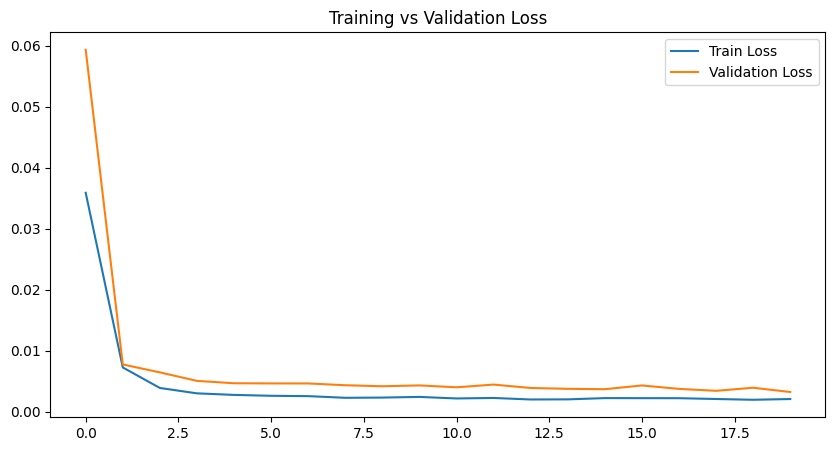

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


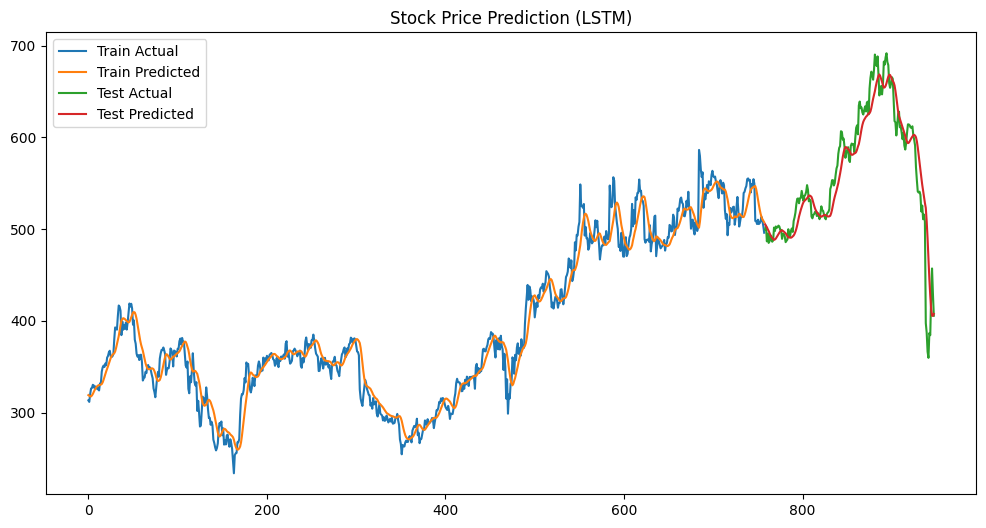

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step

Next Day Prediction: 409.26422


In [ ]:
# =========================
# 📦 INSTALL + IMPORTS
# =========================
!pip install pandas numpy matplotlib scikit-learn tensorflow openpyxl -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================
# 📂 LOAD DATA
# =========================
file_path = "/content/1729258-1613615-Stock_Price_data_set_(1).xlsx"

df = pd.read_excel(file_path)

print("\nColumns:", df.columns)
print(df.head())

# =========================
# 🧹 PREPROCESSING
# =========================
# Handle Date column
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Use Close price (change if needed)
if 'Close' not in df.columns:
    raise Exception("Column 'Close' not found. Check dataset.")

data = df[['Close']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# =========================
# 📊 CREATE SEQUENCES
# =========================
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTraining Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

# =========================
# 🧠 BUILD MODEL
# =========================
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))

model.add(LSTM(100, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

# =========================
# 🚀 TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    verbose=1
)

# =========================
# 📉 LOSS PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# =========================
# 🔮 PREDICTIONS
# =========================
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================
# 📊 PLOT RESULTS
# =========================
plt.figure(figsize=(12,6))

# Train
plt.plot(y_train_actual, label="Train Actual")
plt.plot(train_predict, label="Train Predicted")

# Test
plt.plot(range(len(y_train_actual), len(y_train_actual)+len(y_test_actual)), y_test_actual, label="Test Actual")
plt.plot(range(len(train_predict), len(train_predict)+len(test_predict)), test_predict, label="Test Predicted")

plt.legend()
plt.title("Stock Price Prediction (LSTM)")
plt.show()

# =========================
# 🔮 FUTURE PREDICTION
# =========================
last_60 = scaled_data[-60:]
last_60 = last_60.reshape(1, 60, 1)

future_pred = model.predict(last_60)
future_pred = scaler.inverse_transform(future_pred)

print("\nNext Day Prediction:", future_pred[0][0])

Using CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
        Date        Open        High         Low       Close   Adj Close  \
0 2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1 2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2 2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3 2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4 2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  

Training shape: (782, 30, 1)
Testing shape: (196, 30, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0400 - val_loss: 0.0174
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - val_loss: 0.0047
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0046
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0017 - val_loss: 0.0052
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0017 - val_loss: 0.0064
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0017 - val_loss: 0.0043
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0016 - val_loss: 0.0044
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0016 - val_loss: 0.0039
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016 - val_loss: 0.0050


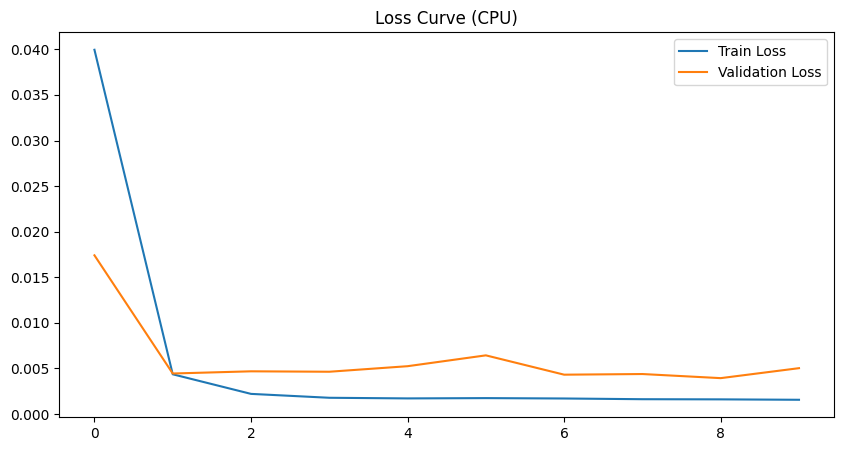

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


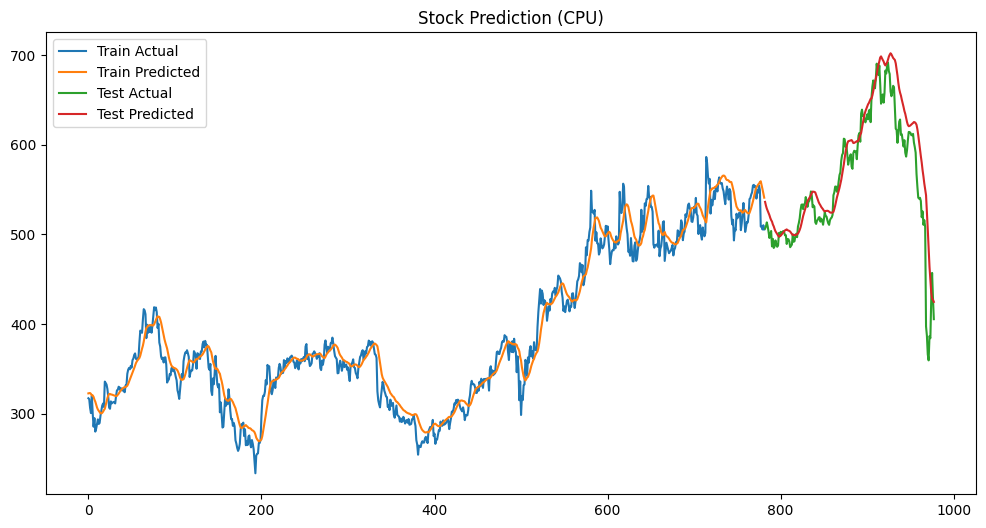

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Next Day Prediction: 418.7208


In [ ]:
=========================
# 📦 INSTALL + IMPORTS
# =========================
!pip install pandas numpy matplotlib scikit-learn tensorflow openpyxl -q

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # 🚫 Force CPU only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import tensorflow as tf
print("Using CPU:", tf.config.list_physical_devices('CPU'))

# =========================
# 📂 LOAD DATA
# =========================
file_path = "/content/1729258-1613615-Stock_Price_data_set_(1).xlsx"

df = pd.read_excel(file_path)

print("\nColumns:", df.columns)
print(df.head())

# =========================
# 🧹 PREPROCESSING
# =========================
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

if 'Close' not in df.columns:
    raise Exception("Column 'Close' not found. Check dataset.")

data = df[['Close']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# =========================
# 📊 CREATE SEQUENCES
# =========================
def create_dataset(data, time_step=30):  # ⬅️ smaller for CPU
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# =========================
# 🧠 BUILD MODEL (LIGHT)
# =========================
model = Sequential()

model.add(LSTM(50, input_shape=(time_step, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

# =========================
# 🚀 TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,          # ⬅️ fewer epochs for CPU
    batch_size=32,
    verbose=1
)

# =========================
# 📉 LOSS PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve (CPU)")
plt.show()

# =========================
# 🔮 PREDICTIONS
# =========================
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================
# 📊 RESULT PLOT
# =========================
plt.figure(figsize=(12,6))

plt.plot(y_train_actual, label="Train Actual")
plt.plot(train_pred, label="Train Predicted")

plt.plot(range(len(y_train_actual), len(y_train_actual)+len(y_test_actual)), y_test_actual, label="Test Actual")
plt.plot(range(len(train_pred), len(train_pred)+len(test_pred)), test_pred, label="Test Predicted")

plt.legend()
plt.title("Stock Prediction (CPU)")
plt.show()

# =========================
# 🔮 NEXT DAY PREDICTION
# =========================
last_seq = scaled_data[-time_step:]
last_seq = last_seq.reshape(1, time_step, 1)

future = model.predict(last_seq)
future = scaler.inverse_transform(future)

print("\nNext Day Prediction:", future[0][0])

GPU Available: []


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

====== EXECUTION TIME ======
CPU Training Time  : 7.41 seconds
GPU Training Time  : 45.65 seconds

====== FINAL LOSS ======
CPU Loss : 0.001622
GPU Loss : 0.001628


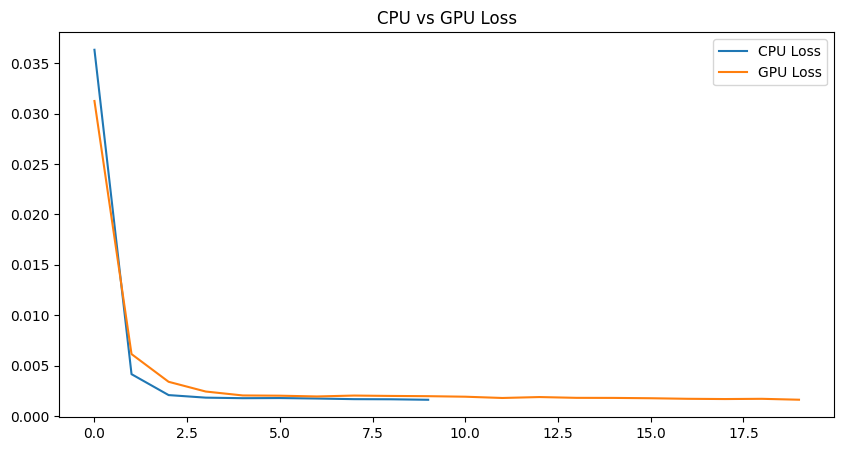

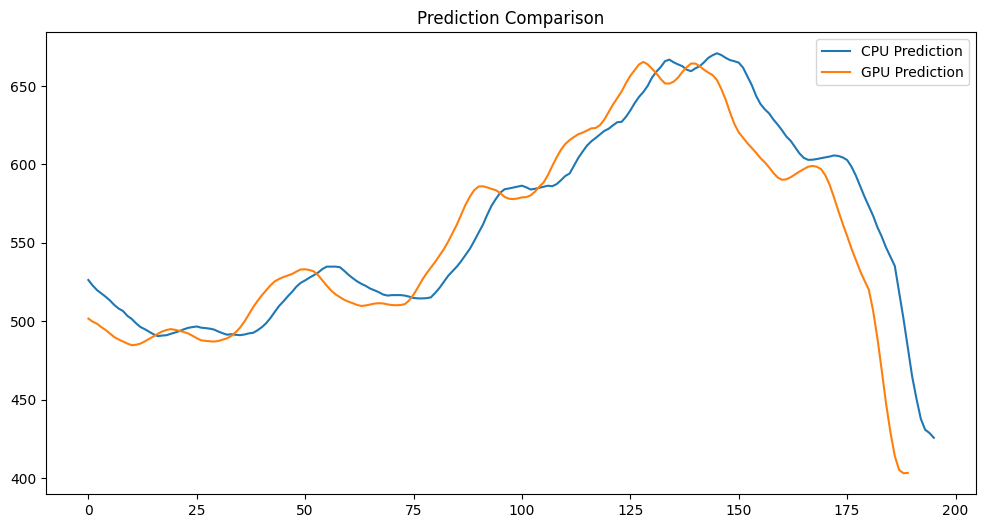

In [ ]:
# =========================
# 📦 INSTALL + IMPORTS
# =========================
!pip install pandas numpy matplotlib scikit-learn tensorflow openpyxl -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================
# 📂 LOAD DATA
# =========================
file_path = "/content/1729258-1613615-Stock_Price_data_set_(1).xlsx"
df = pd.read_excel(file_path)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

data = df[['Close']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# =========================
# 📊 CREATE DATASET FUNCTION
# =========================
def create_dataset(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# =========================
# 🔵 CPU MODEL
# =========================
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

time_step_cpu = 30
X_cpu, y_cpu = create_dataset(scaled_data, time_step_cpu)
X_cpu = X_cpu.reshape(X_cpu.shape[0], X_cpu.shape[1], 1)

split = int(len(X_cpu)*0.8)
Xc_train, Xc_test = X_cpu[:split], X_cpu[split:]
yc_train, yc_test = y_cpu[:split], y_cpu[split:]

cpu_model = Sequential([
    LSTM(50, input_shape=(time_step_cpu,1)),
    Dense(1)
])

cpu_model.compile(optimizer='adam', loss='mse')

start_cpu = time.time()

cpu_history = cpu_model.fit(
    Xc_train, yc_train,
    epochs=10,
    batch_size=32,
    verbose=0
)

cpu_time = time.time() - start_cpu

cpu_pred = cpu_model.predict(Xc_test)

# =========================
# 🟢 GPU MODEL
# =========================
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # enable GPU if exists

time_step_gpu = 60
X_gpu, y_gpu = create_dataset(scaled_data, time_step_gpu)
X_gpu = X_gpu.reshape(X_gpu.shape[0], X_gpu.shape[1], 1)

split = int(len(X_gpu)*0.8)
Xg_train, Xg_test = X_gpu[:split], X_gpu[split:]
yg_train, yg_test = y_gpu[:split], y_gpu[split:]

gpu_model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(time_step_gpu,1)),
    Dropout(0.2),
    LSTM(100),
    Dense(1)
])

gpu_model.compile(optimizer='adam', loss='mse')

start_gpu = time.time()

gpu_history = gpu_model.fit(
    Xg_train, yg_train,
    epochs=20,
    batch_size=64,
    verbose=0
)

gpu_time = time.time() - start_gpu

gpu_pred = gpu_model.predict(Xg_test)

# =========================
# 📊 RESULTS COMPARISON
# =========================
print("\n====== EXECUTION TIME ======")
print(f"CPU Training Time  : {cpu_time:.2f} seconds")
print(f"GPU Training Time  : {gpu_time:.2f} seconds")

print("\n====== FINAL LOSS ======")
print(f"CPU Loss : {cpu_history.history['loss'][-1]:.6f}")
print(f"GPU Loss : {gpu_history.history['loss'][-1]:.6f}")

# =========================
# 📉 LOSS COMPARISON PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(cpu_history.history['loss'], label="CPU Loss")
plt.plot(gpu_history.history['loss'], label="GPU Loss")
plt.legend()
plt.title("CPU vs GPU Loss")
plt.show()

# =========================
# 📈 PREDICTION COMPARISON
# =========================
cpu_pred = scaler.inverse_transform(cpu_pred)
gpu_pred = scaler.inverse_transform(gpu_pred)

plt.figure(figsize=(12,6))
plt.plot(cpu_pred, label="CPU Prediction")
plt.plot(gpu_pred, label="GPU Prediction")
plt.legend()
plt.title("Prediction Comparison")
plt.show()